# Unit execution for `noise_resilience_common.py`

This notebook checks the generic sweep helper before wiring it into the real
`subnorm`, `timeevo/ZZ`, and `timeevo/ampdamp` workflows.

It demonstrates:
- conversion between decay-rate and per-step probability,
- building compatible `SimpleNISQNoiseParameters` objects,
- running a manual dummy sweep callback,
- summarizing repeated-run results into mean/std tables.


In [1]:
import numpy as np
import pandas as pd

import os
import sys

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from noise.noise_simulation import SimpleNISQNoiseParameters
from noise.noise_resilience_common import (
    NoiseSweepSpecification,
    build_noise_parameters_for_sweep,
    linear_sweep,
    log_sweep,
    probability_from_decay_rate,
    equivalent_relaxation_time_from_probability,
    equivalent_dephasing_time_from_probability,
    run_noise_resilience_sweep,
    summarize_noise_resilience_results,
    noise_parameters_to_dict,
)

np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.max_columns', None)


## 1. Tweakable base noise parameters

In [2]:
base_params = SimpleNISQNoiseParameters(
    t1_system=np.inf,
    t2_system=np.inf,
    t1_ancilla=np.inf,
    t2_ancilla=np.inf,
    one_qubit_gate_time=20e-9,
    two_qubit_gate_time=200e-9,
    p1q_depolarizing=0.0,
    p2q_depolarizing=0.0,
    readout_p0_to_1_system=0.0,
    readout_p1_to_0_system=0.0,
    readout_p0_to_1_ancilla=0.0,
    readout_p1_to_0_ancilla=0.0,
)

noise_parameters_to_dict(base_params)


{'t1_system': inf,
 't2_system': inf,
 't1_ancilla': inf,
 't2_ancilla': inf,
 'one_qubit_gate_time': 2e-08,
 'two_qubit_gate_time': 2e-07,
 'p1q_depolarizing': 0.0,
 'p2q_depolarizing': 0.0,
 'readout_p0_to_1_system': 0.0,
 'readout_p1_to_0_system': 0.0,
 'readout_p0_to_1_ancilla': 0.0,
 'readout_p1_to_0_ancilla': 0.0}

## 2. Probability / rate conversions

In [3]:
duration = base_params.two_qubit_gate_time
amplitude_decay_rate = 2.5e6     # 1 / second, change freely
phase_decay_rate = 5.0e6         # 1 / second, change freely

p_ad = probability_from_decay_rate(amplitude_decay_rate, duration)
p_pd = probability_from_decay_rate(phase_decay_rate, duration)

t1_equiv = equivalent_relaxation_time_from_probability(p_ad, duration)
tphi_equiv = equivalent_dephasing_time_from_probability(p_pd, duration)

print('duration =', duration)
print('p_ad =', p_ad)
print('p_pd =', p_pd)
print('equivalent T1 =', t1_equiv)
print('equivalent Tphi =', tphi_equiv)


duration = 2e-07
p_ad = 0.3934693402873666
p_pd = 0.6321205588285577
equivalent T1 = 4e-07
equivalent Tphi = 2e-07


## 3. Build sweep-compatible noise parameter objects

In [5]:
params_ad = build_noise_parameters_for_sweep(
    base_params,
    noise_kind='amplitude_damping',
    sweep_value=0.03,
    parameterization='probability',
    duration=base_params.two_qubit_gate_time,
    isolate_noise=True,
    apply_to='both',
)

params_pd = build_noise_parameters_for_sweep(
    base_params,
    noise_kind='phase_damping',
    sweep_value=0.04,
    parameterization='probability',
    duration=base_params.two_qubit_gate_time,
    isolate_noise=True,
    apply_to='system',
)

params_dep = build_noise_parameters_for_sweep(
    base_params,
    noise_kind='depolarizing',
    sweep_value=0.02,
    parameterization='probability',
    isolate_noise=True,
    depolarizing_mode='both',
)

params_ro = build_noise_parameters_for_sweep(
    base_params,
    noise_kind='readout',
    sweep_value=0.05,
    parameterization='probability',
    isolate_noise=True,
    apply_to='ancilla',
)

print('Amplitude damping params:')
print(noise_parameters_to_dict(params_ad))
print('Phase damping params:')
print(noise_parameters_to_dict(params_pd))
print('Depolarizing params:')
print(noise_parameters_to_dict(params_dep))
print('Readout params:')
print(noise_parameters_to_dict(params_ro))


Amplitude damping params:
{'t1_system': 6.566159021058113e-06, 't2_system': inf, 't1_ancilla': 6.566159021058113e-06, 't2_ancilla': inf, 'one_qubit_gate_time': 2e-08, 'two_qubit_gate_time': 2e-07, 'p1q_depolarizing': 0.0, 'p2q_depolarizing': 0.0, 'readout_p0_to_1_system': 0.0, 'readout_p1_to_0_system': 0.0, 'readout_p0_to_1_ancilla': 0.0, 'readout_p1_to_0_ancilla': 0.0}
Phase damping params:
{'t1_system': inf, 't2_system': 4.899319652320355e-06, 't1_ancilla': inf, 't2_ancilla': inf, 'one_qubit_gate_time': 2e-08, 'two_qubit_gate_time': 2e-07, 'p1q_depolarizing': 0.0, 'p2q_depolarizing': 0.0, 'readout_p0_to_1_system': 0.0, 'readout_p1_to_0_system': 0.0, 'readout_p0_to_1_ancilla': 0.0, 'readout_p1_to_0_ancilla': 0.0}
Depolarizing params:
{'t1_system': inf, 't2_system': inf, 't1_ancilla': inf, 't2_ancilla': inf, 'one_qubit_gate_time': 2e-08, 'two_qubit_gate_time': 2e-07, 'p1q_depolarizing': 0.02, 'p2q_depolarizing': 0.02, 'readout_p0_to_1_system': 0.0, 'readout_p1_to_0_system': 0.0, 'reado

## 4. Tweakable manual sweep grids

In [6]:
linear_values = linear_sweep(0.0, 0.08, 6)
log_values = log_sweep(1e-4, 1e-1, 5)

print('linear_values =', linear_values)
print('log_values =', log_values)


linear_values = [0.    0.016 0.032 0.048 0.064 0.08 ]
log_values = [0.0001   0.000562 0.003162 0.017783 0.1     ]


## 5. Dummy runner for testing the sweep engine

This is only a placeholder. Replace it later with the actual `subnorm`, `ZZ`,
or `ampdamp` runner.


In [7]:
def dummy_runner(noise_params, sweep_value, repeat_index, rng, *, baseline_fidelity=0.995, baseline_success=0.985):
    # A simple toy severity model based on the swept value and the resulting parameter object.
    severity = float(sweep_value)
    severity += 0.6 * float(noise_params.p2q_depolarizing)
    severity += 0.2 * float(noise_params.p1q_depolarizing)
    severity += 0.4 * float(noise_params.readout_p0_to_1_ancilla + noise_params.readout_p1_to_0_ancilla)

    fidelity = baseline_fidelity - 1.2 * severity + rng.normal(0.0, 0.002)
    success = baseline_success - 0.8 * severity + rng.normal(0.0, 0.003)

    fidelity = float(np.clip(fidelity, 0.0, 1.0))
    success = float(np.clip(success, 0.0, 1.0))

    return {
        'fidelity': fidelity,
        'success_probability': success,
    }


## 6. Run a depolarizing sweep

In [8]:
specification = NoiseSweepSpecification(
    noise_kind='depolarizing',
    sweep_values=linear_sweep(0.0, 0.06, 7),
    parameterization='probability',
    isolate_noise=True,
    depolarizing_mode='both',
)

sweep_result = run_noise_resilience_sweep(
    dummy_runner,
    base_params=base_params,
    specification=specification,
    repeats=5,
    rng_seed=1234,
)

print('Raw results:')
display(sweep_result.raw_results.head())

print('Summary results:')
display(sweep_result.summary_results)


Raw results:


,noise_kind,parameterization,sweep_index,sweep_value,repeat_index,fidelity,success_probability
0,depolarizing,probability,0,0.0,0,0.991792,0.985192
1,depolarizing,probability,0,0.0,1,0.996482,0.985458
2,depolarizing,probability,0,0.0,2,0.996727,0.993739
3,depolarizing,probability,0,0.0,3,0.992042,0.987836
4,depolarizing,probability,0,0.0,4,0.991668,0.986031


Summary results:


,noise_kind,parameterization,sweep_value,fidelity_mean,fidelity_std,success_probability_mean,success_probability_std
0,depolarizing,probability,0.00,0.993742,0.002618,0.987651,0.003556
1,depolarizing,probability,0.01,0.972727,0.001580,0.970849,0.004897
2,depolarizing,probability,0.02,0.952378,0.001422,0.955812,0.002301
3,depolarizing,probability,0.03,0.930006,0.002248,0.939210,0.003230
4,depolarizing,probability,0.04,0.907208,0.001824,0.928057,0.004816
5,depolarizing,probability,0.05,0.886561,0.002274,0.916109,0.003151
6,depolarizing,probability,0.06,0.866240,0.002122,0.898227,0.001263


## 7. Run an amplitude-damping sweep using decay rates

In [9]:
specification_rate = NoiseSweepSpecification(
    noise_kind='amplitude_damping',
    sweep_values=linear_sweep(0.0, 8.0e6, 6),
    parameterization='rate',
    duration=base_params.two_qubit_gate_time,
    isolate_noise=True,
    apply_to='both',
)

sweep_result_rate = run_noise_resilience_sweep(
    dummy_runner,
    base_params=base_params,
    specification=specification_rate,
    repeats=4,
    rng_seed=2026,
)

display(sweep_result_rate.summary_results)


,noise_kind,parameterization,sweep_value,fidelity_mean,fidelity_std,success_probability_mean,success_probability_std
0,amplitude_damping,rate,0.0,0.993818,0.002108,0.986236,0.002125
1,amplitude_damping,rate,1600000.0,0.000000,0.000000,0.000000,0.000000
2,amplitude_damping,rate,3200000.0,0.000000,0.000000,0.000000,0.000000
3,amplitude_damping,rate,4800000.0,0.000000,0.000000,0.000000,0.000000
4,amplitude_damping,rate,6400000.0,0.000000,0.000000,0.000000,0.000000
5,amplitude_damping,rate,8000000.0,0.000000,0.000000,0.000000,0.000000


## 8. Optional manual re-summary

In [10]:
manual_summary = summarize_noise_resilience_results(
    sweep_result.raw_results,
    metric_columns=['fidelity', 'success_probability'],
)
manual_summary


,noise_kind,parameterization,sweep_value,fidelity_mean,fidelity_std,success_probability_mean,success_probability_std
0,depolarizing,probability,0.00,0.993742,0.002618,0.987651,0.003556
1,depolarizing,probability,0.01,0.972727,0.001580,0.970849,0.004897
2,depolarizing,probability,0.02,0.952378,0.001422,0.955812,0.002301
3,depolarizing,probability,0.03,0.930006,0.002248,0.939210,0.003230
4,depolarizing,probability,0.04,0.907208,0.001824,0.928057,0.004816
5,depolarizing,probability,0.05,0.886561,0.002274,0.916109,0.003151
6,depolarizing,probability,0.06,0.866240,0.002122,0.898227,0.001263


## 9. Minimal plot check

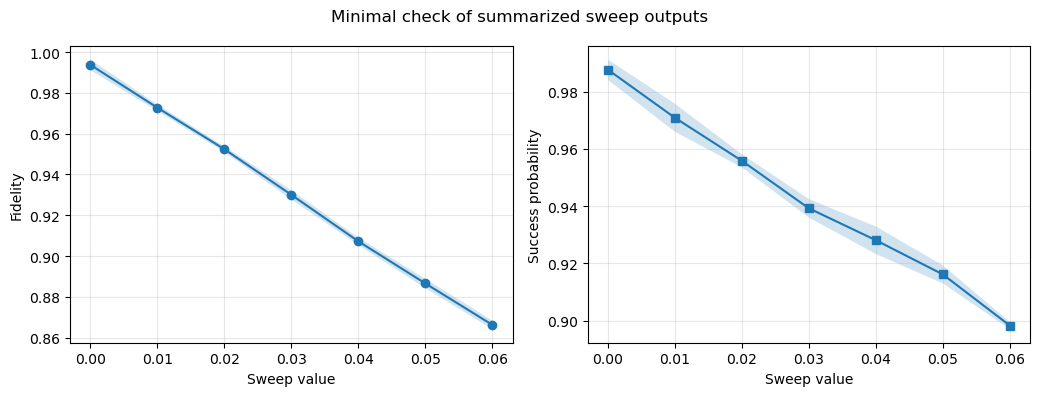

In [11]:
import matplotlib.pyplot as plt

summary = sweep_result.summary_results

fig, axs = plt.subplots(1, 2, figsize=(10.5, 4.0), sharex=True)
axs[0].plot(summary['sweep_value'], summary['fidelity_mean'], marker='o')
axs[0].fill_between(
    summary['sweep_value'],
    summary['fidelity_mean'] - summary['fidelity_std'],
    summary['fidelity_mean'] + summary['fidelity_std'],
    alpha=0.2,
)
axs[0].set_xlabel('Sweep value')
axs[0].set_ylabel('Fidelity')
axs[0].grid(True, alpha=0.3)

axs[1].plot(summary['sweep_value'], summary['success_probability_mean'], marker='s')
axs[1].fill_between(
    summary['sweep_value'],
    summary['success_probability_mean'] - summary['success_probability_std'],
    summary['success_probability_mean'] + summary['success_probability_std'],
    alpha=0.2,
)
axs[1].set_xlabel('Sweep value')
axs[1].set_ylabel('Success probability')
axs[1].grid(True, alpha=0.3)

fig.suptitle('Minimal check of summarized sweep outputs')
fig.tight_layout()
plt.show()
